
Naive Bayes
Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1-score : 0.8571428571428571

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



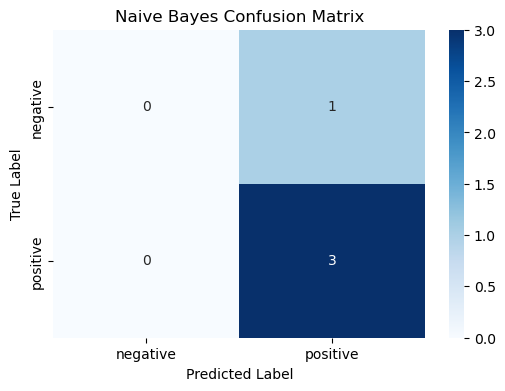


SVM
Accuracy : 0.75
Precision: 0.75
Recall   : 1.0
F1-score : 0.8571428571428571

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



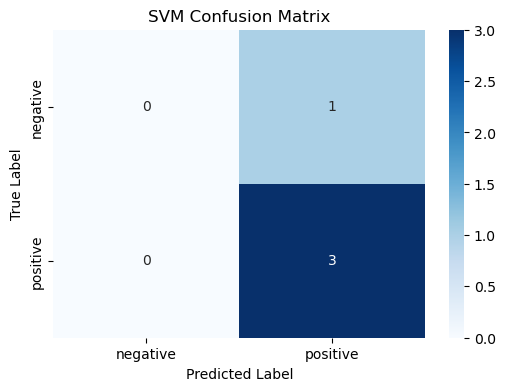

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Load original file
df = pd.read_csv("Processed_Reviews.csv")

# 2. Add label column manually
# positive = 1, negative = 0
# Suggested labels based on the reviews
df["label"] = [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1]

# Optional: save back into the same original file
df.to_csv("Processed_Reviews.csv", index=False)

# 3. Use only lemmatized column and label
data = df[["lemmatized", "label"]].dropna()

# If labels are text in future, convert them
if data["label"].dtype == "object":
    data["label"] = data["label"].map({"positive": 1, "negative": 0})

# 4. Vectorization
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(data["lemmatized"])
y = data["label"]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 6. Train models
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)

svm_clf = SVC(kernel="linear")
svm_clf.fit(X_train, y_train)

# 7. Predict
nb_pred = nb_clf.predict(X_test)
svm_pred = svm_clf.predict(X_test)

# 8. Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['negative', 'positive'],
        yticklabels=['negative', 'positive']
    )
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# 9. Show results
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("SVM", y_test, svm_pred)